In [2]:
import numpy as tnp

import matplotlib.pyplot as plt
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus,
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    circle,
    spider,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation


%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
!nvidia-smi

Tue Dec  9 11:00:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   30C    P0             64W /  300W |     929MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## num stars trade

In [ ]:
npix_pupil = 256
d_pupil = 3000
dx_pupil = d_pupil / npix_pupil
fno = 15
efl = d_pupil * fno
wvl = 0.633
npix_focal = 128
dx_focal = 3.76 # 9.5

x, y = make_xy_grid(shape=npix_pupil, diameter=d_pupil)
r, t = cart_to_polar(x, y)
r_norm = r / (d_pupil / 2)

A = circle(radius=d_pupil / 2, r=r)
A = A / np.sqrt(A.sum())

nms = [noll_to_nm(i) for i in range(1, 37)]
zernikes = np.array(zernike_nm_seq(nms, r_norm, t, norm=True))
# zernikes = np.array([z / np.max(np.abs(z)) for z in zernikes])

inds = [i + 3 for i in range(8)]

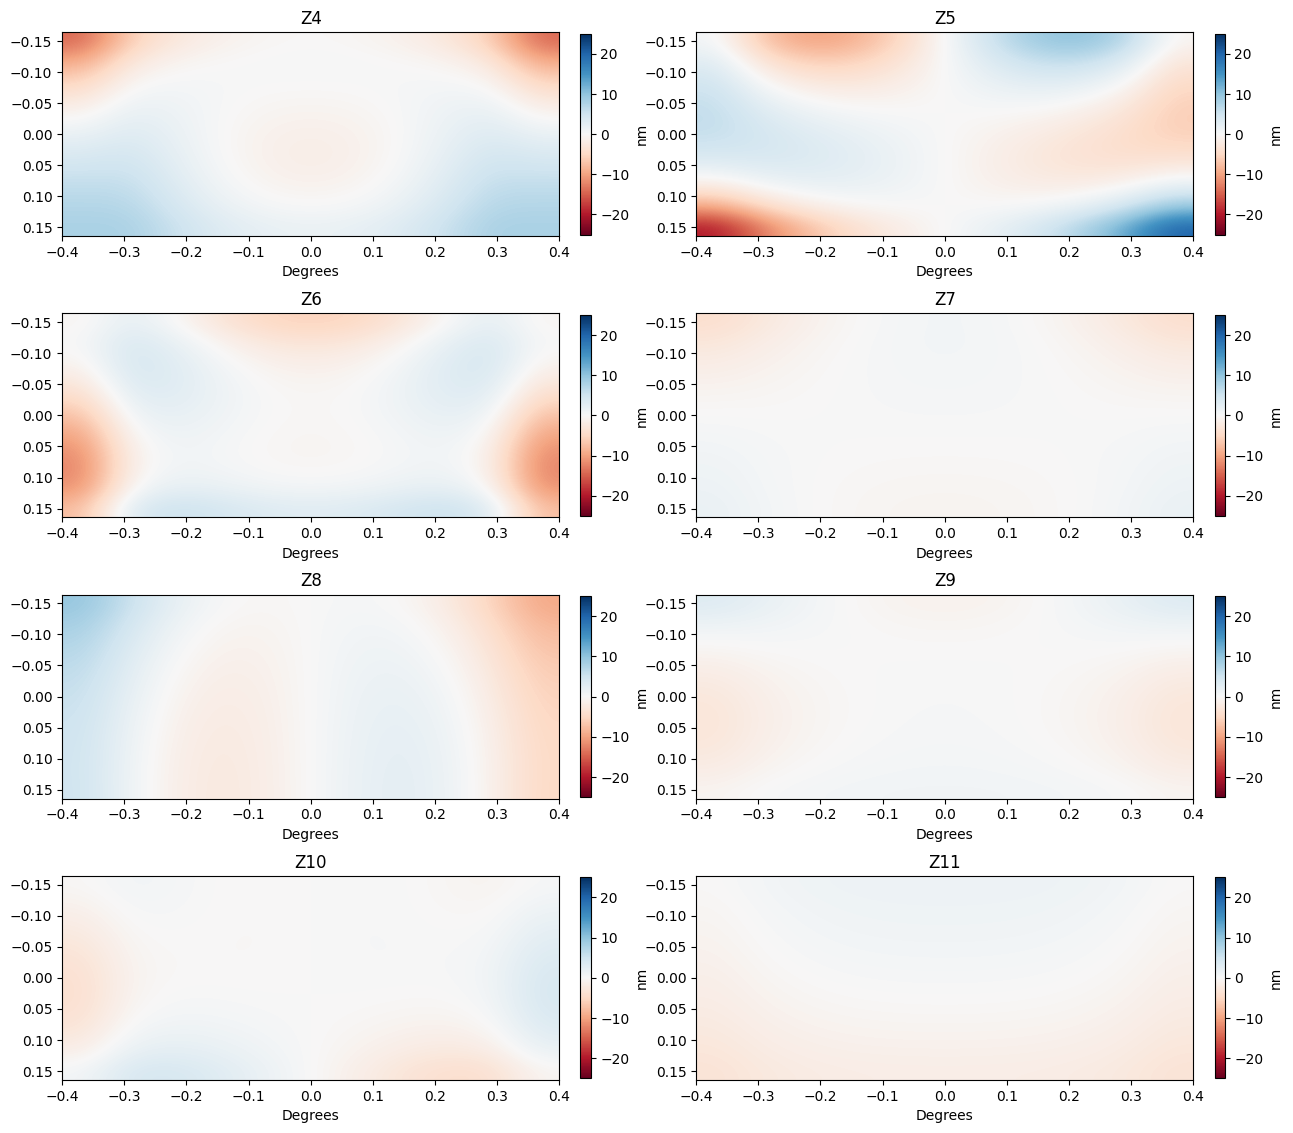

In [31]:
fnames = ["Z4", "Z5", "Z6", "Z7", "Z8", "Z9", "Z10", "Z11"]
path = "/home/derbyk/src/ffpr/data/new_fields/"

# Prepare a 12x12 array filled with zeros
field_coeffs_nom = tnp.zeros((len(fnames), 11, 11))

coeff_index = 0

for z, fname in enumerate(fnames):

    arr = tnp.zeros((12, 12))

    with open(path+fname+".txt", "r", encoding="utf-16") as f:
        lines = f.readlines()

    row_index = 0

    for i, line in enumerate(lines):
        
        if i > 22:

            line = line.strip()

            # Skip empty or separator rows
            if not line or "====" in line:
                continue

            # HEADER ROW (no "||")
            if "||" not in line:
                # Parse the x-values
                parts = line.split()
                nums = [float(x) for x in parts]

                # Insert into row 0, columns 1..11
                arr[0, 1:1+len(nums)] = nums
                row_index += 1
                continue

            # DATA ROWS (contain "||")
            line = line.replace("||", " ")
            parts = line.split()
            nums = [float(x) for x in parts]

            # First value goes into column 0 (y-value)
            arr[row_index, 0] = nums[0]

            # Remaining 11 values go into columns 1..11
            arr[row_index, 1:12] = nums[1:]

            row_index += 1

    # if z == 0:
        # arr[-2, 6] += -5
        # arr[6, 3] += 1
        # arr[6, 9] += -1

    field_coeffs_nom[coeff_index, : , :] = arr[1:, 1:] * wvl * 1e3

    coeff_index += 1

fields_x = arr[0, 1:]
fields_y = arr[1:, 0]

# create interpolators for field-dependent zernikes
field_interps_nom = [interpolate.RegularGridInterpolator((fields_x, fields_y), field_coeffs_nom[i, :, :], method='cubic') for i in range(field_coeffs_nom.shape[0])]

# show field dependence for field-dependent zernikes
plt.figure(figsize=(15, 14))
for i in range(field_coeffs_nom.shape[0]):
    plt.subplot(4, 2, i + 1)
    plt.title(f'Z{i + 4:.0f}')
    plt.imshow(field_coeffs_nom[i, :, :], interpolation='bicubic', extent=[fields_x[0], fields_x[-1], fields_y[0], fields_y[-1]], vmin=-25, vmax=25, cmap='RdBu')
    plt.xlabel('Degrees')
    plt.colorbar(fraction=0.019, pad=0.04, label='nm')

In [17]:
collecting_area = np.pi * (150 ** 2)                              # [cm^2]
bandwidth = (0.7 - 0.55) * 1e-6                           # [um -> m]
flux = 702e10 * collecting_area * bandwidth * 10 ** (-15 / 2.5)  # [photons/s]
photons = flux * 1

print(photons)

74432.18394517613


In [32]:
n_stars_range = np.linspace(1, 10, 10)
n_photons_range = np.array([1e3, 1e4, 1e5])

opd_rms = 10
samples = 100

cr_bounds = np.zeros((len(n_photons_range), len(n_stars_range)))

for m, n_photons in enumerate(n_photons_range):

    print(str(n_photons) + ' photons...')

    for n, n_stars in enumerate(n_stars_range):

        n_stars = int(n_stars)

        print(str(n_stars) + ' stars...', end='\r')

        cr_bound = 0

        for i in range(samples):

            positions_x = np.random.uniform(low=fields_x[0], high=fields_x[-1], size=n_stars)
            positions_y = np.random.uniform(low=fields_y[-1], high=fields_y[0], size=n_stars)
            positions = [(float(x), float(y)) for x, y in zip(positions_x, positions_y)]

            coeffs_field = [[interp(np.array(position)) for interp in field_interps_nom] for position in positions]

            coeffs_opd = np.random.normal(loc=0, size=len(zernikes[inds]))
            opd = sum_of_2d_modes(zernikes[inds], coeffs_opd)
            opd *= opd_rms / np.sqrt(np.mean(opd[A.astype('bool')] ** 2))

            deltas = [sum_of_2d_modes(modes=zernikes[inds], weights=np.array(coeffs)).squeeze() for coeffs in coeffs_field]

            phis = [(2 * np.pi / wvl) * (opd + delta) for delta in deltas]

            gs = [A * np.exp(1j * phi) for phi in phis]

            Gs = [focus_fixed_sampling(wavefunction=g, input_dx=dx_pupil, prop_dist=efl, wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal) for g in gs]

            Is = [np.abs(G) ** 2 for G in Gs]

            fisher_matrix = np.zeros((len(zernikes[inds]), len(zernikes[inds])))

            for g, G, I in zip(gs, Gs, Is):

                p1 = np.zeros((len(zernikes[inds]), npix_focal ** 2))

                for k in range(len(zernikes[inds])):

                    p1[k, :] = (np.conj(G) * focus_fixed_sampling(wavefunction=g * zernikes[inds][k], input_dx=dx_pupil, prop_dist=efl, 
                                                                        wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal)).imag.ravel()

                p2 = p1[None, :, :] * p1[:, None, :]

                p3 = p2 * n_photons * 4 / I.ravel()[None, None, :]

                fisher_matrix += np.sum(p3, axis=2)

            cov_matrix = np.linalg.inv(fisher_matrix)
        
            cr_bound += np.trace(cov_matrix) / samples
        
        cr_bounds[m, n] = cr_bound

1000.0 photons...
10000.0 photons...
100000.0 photons...


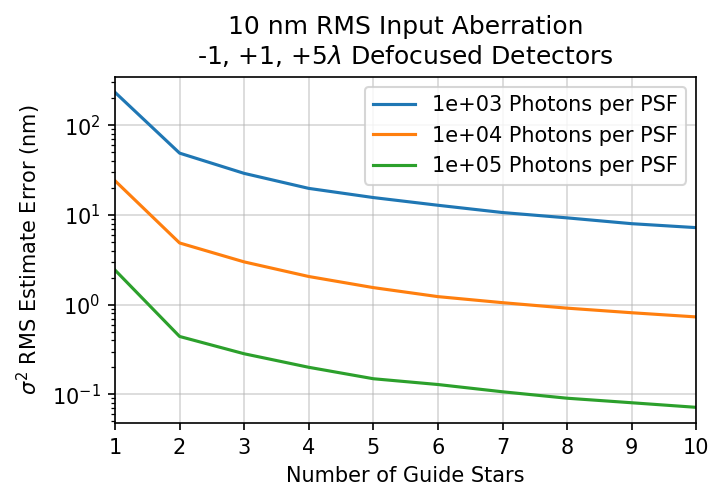

In [24]:
plt.figure(figsize=(5, 3), dpi=150)
for i in range(len(n_photons_range)):
    plt.semilogy(n_stars_range.get(), cr_bounds.get()[i, :] * 633, label=f'{n_photons_range[i]:.0e} Photons per PSF')
plt.xlabel('Number of Guide Stars')
plt.xticks(range(1, 11))
plt.xlim([1, 10])
plt.ylabel('$\sigma^2$ RMS Estimate Error (nm)')
# plt.yticks(range(10, 101, 10))
plt.grid(alpha=0.5)
plt.title('10 nm RMS Input Aberration\n-1, +1, +5$\lambda$ Defocused Detectors')
plt.legend()

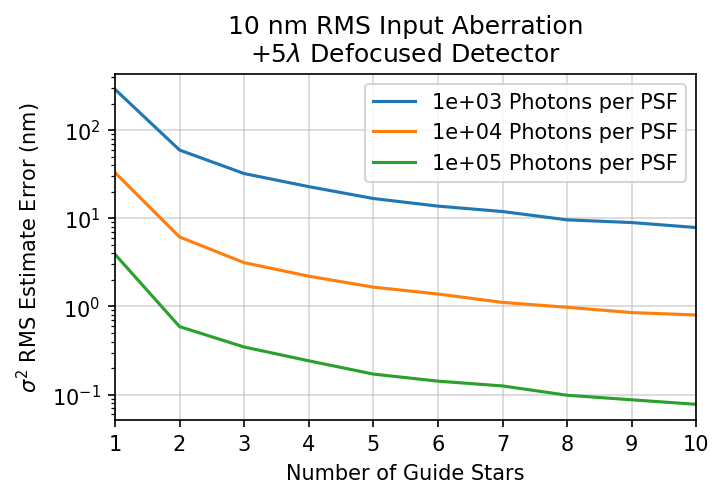

In [29]:
plt.figure(figsize=(5, 3), dpi=150)
for i in range(len(n_photons_range)):
    plt.semilogy(n_stars_range.get(), cr_bounds.get()[i, :] * 633, label=f'{n_photons_range[i]:.0e} Photons per PSF')
plt.xlabel('Number of Guide Stars')
plt.xticks(range(1, 11))
plt.xlim([1, 10])
plt.ylabel('$\sigma^2$ RMS Estimate Error (nm)')
# plt.yticks(range(10, 101, 10))
plt.grid(alpha=0.5)
plt.title('10 nm RMS Input Aberration\n+5$\lambda$ Defocused Detector')
plt.legend()

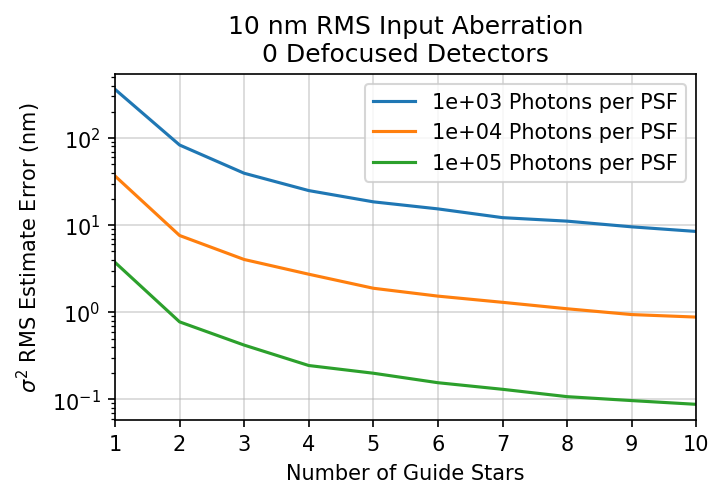

In [34]:
plt.figure(figsize=(5, 3), dpi=150)
for i in range(len(n_photons_range)):
    plt.semilogy(n_stars_range.get(), cr_bounds.get()[i, :] * 633, label=f'{n_photons_range[i]:.0e} Photons per PSF')
plt.xlabel('Number of Guide Stars')
plt.xticks(range(1, 11))
plt.xlim([1, 10])
plt.ylabel('$\sigma^2$ RMS Estimate Error (nm)')
# plt.yticks(range(10, 101, 10))
plt.grid(alpha=0.5)
plt.title('10 nm RMS Input Aberration\n0 Defocused Detectors')
plt.legend()

## diversity trade

In [4]:
def calc_cr_bounds(samples, fx_diversity, n_photons, coeff_diversities, opd_rms_vals):

    cr_bounds = np.zeros((len(coeff_diversities), len(opd_rms_vals)))

    for t, opd_rms in enumerate(opd_rms_vals):

        for s, coeff_diversity in enumerate(coeff_diversities):

            coeffs_diversity = [0, coeff_diversity]

            for i in range(samples):

                coeffs_opd = np.random.normal(loc=0, size=len(zernikes))

                opd = sum_of_2d_modes(zernikes, coeffs_opd)
                
                opd *= opd_rms / np.sqrt(np.mean(opd[A.astype('bool')] ** 2))

                deltas = [fx_diversity * wvl * coeff for coeff in coeffs_diversity]

                phis = [(2 * np.pi / wvl) * (opd + delta) for delta in deltas]

                gs = [A * np.exp(1j * phi) for phi in phis]

                Gs = [focus_fixed_sampling(wavefunction=g, input_dx=dx_pupil, prop_dist=efl, wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal) for g in gs]

                Is = [np.abs(G) ** 2 for G in Gs]

                fisher_matrix = np.zeros((len(zernikes), len(zernikes)))

                for g, G, I in zip(gs, Gs, Is):

                    p1 = np.zeros((len(zernikes), npix_focal ** 2))

                    for j in range(len(zernikes)):

                        p1[j, :] = (np.conj(G) * focus_fixed_sampling(wavefunction=g * zernikes[j], input_dx=dx_pupil, prop_dist=efl, 
                                                                            wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal)).imag.ravel()

                    p2 = p1[None, :, :] * p1[:, None, :]

                    p3 = p2 * n_photons * 4 / I.ravel()[None, None, :]

                    fisher_matrix += np.sum(p3, axis=2)

                cov_matrix = np.linalg.inv(fisher_matrix)
            
                cr_bound = np.trace(cov_matrix)

                cr_bounds[s, t] += cr_bound / samples

    return cr_bounds

In [ ]:
npix_pupil = 256
d_pupil = 3000
dx_pupil = d_pupil / npix_pupil
fno = 15
efl = d_pupil * fno
wvl = 0.633
npix_focal = 128
dx_focal = 9.5 # 3.76

x, y = make_xy_grid(shape=npix_pupil, diameter=d_pupil)
r, t = cart_to_polar(x, y)
r_norm = r / (d_pupil / 2)

A = circle(radius=d_pupil / 2, r=r)
A = A / np.sqrt(A.sum())

nms = [noll_to_nm(i) for i in range(4, 12)]
zernikes = np.array(zernike_nm_seq(nms, r_norm, t, norm=True))
# zernikes = np.array([z / np.max(np.abs(z)) for z in zernikes])

Text(0, 0.5, 'RMS Diversity (Waves)')

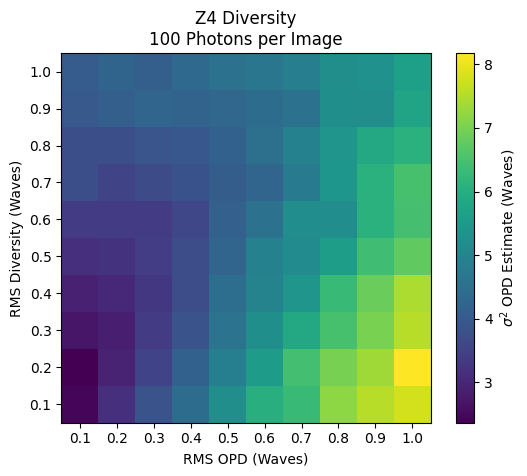

In [57]:
samples = 100
fx_diversity = zernikes[0]
n_photons = 1

coeff_diversities = np.linspace(0.1, 1, 10)
opd_rms_vals = np.linspace(wvl / 10, wvl, 10) 


cr_bounds = calc_cr_bounds(samples=samples, fx_diversity=zernikes[0], n_photons=n_photons, coeff_diversities=coeff_diversities, opd_rms_vals=opd_rms_vals)

plt.figure()
plt.title('Z4 Diversity\n100 Photons per Image')
plt.imshow(cr_bounds.get(), origin='lower')
plt.colorbar(label='$\sigma^2$ OPD Estimate (Waves)')

plt.xticks(range(cr_bounds.shape[1]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
plt.xlabel('RMS OPD (Waves)')

plt.yticks(range(cr_bounds.shape[0]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
plt.ylabel('RMS Diversity (Waves)')

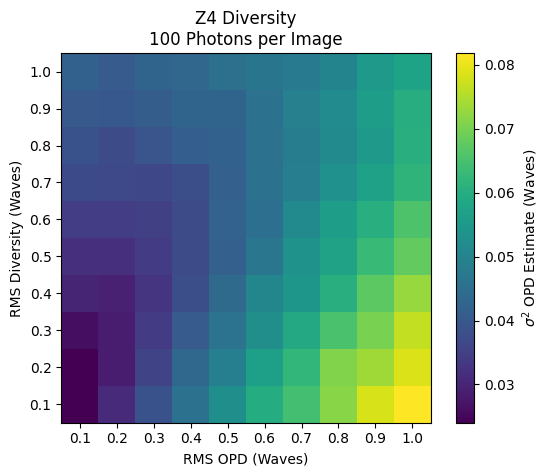

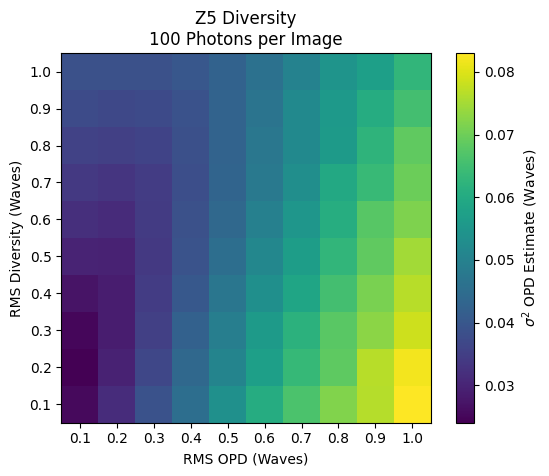

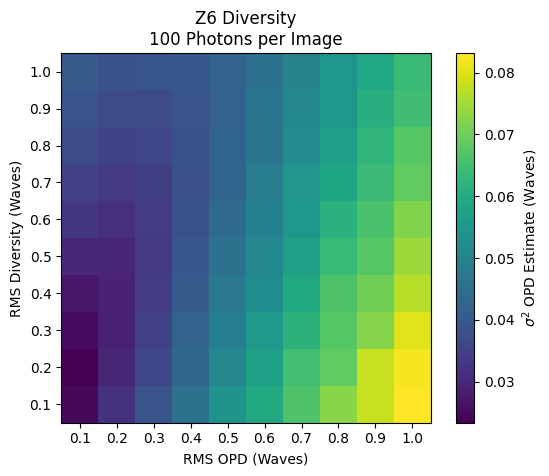

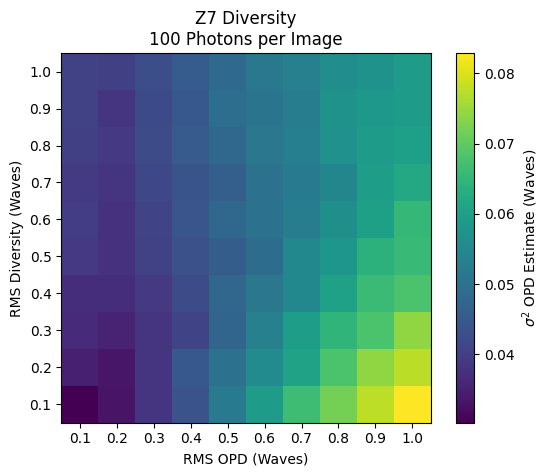

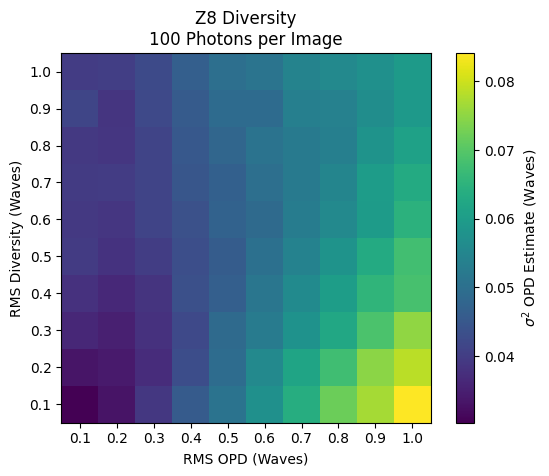

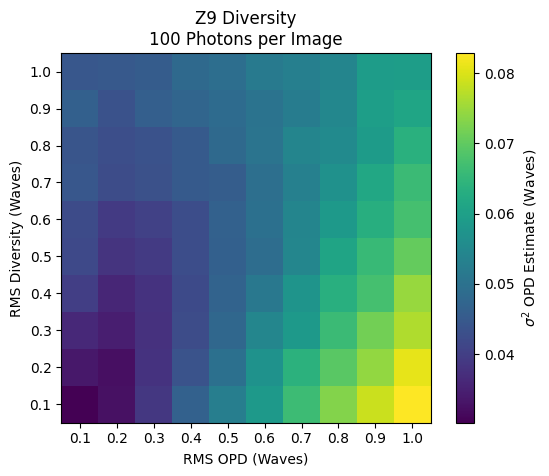

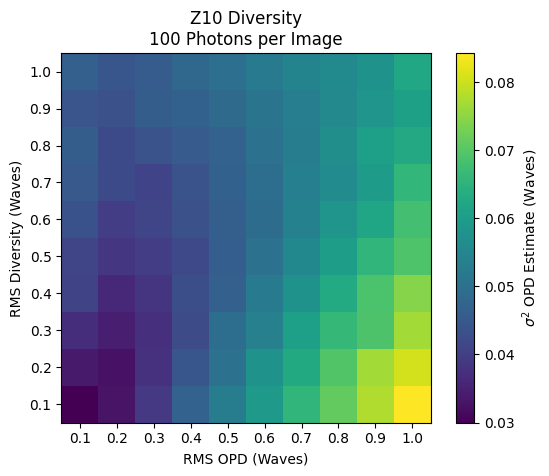

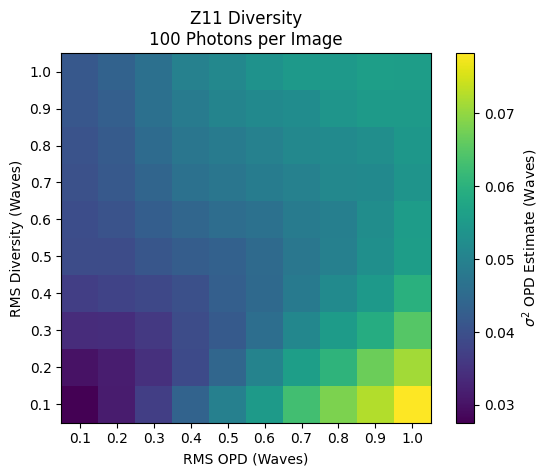

In [5]:
samples = 500
fx_diversity = zernikes[0]
n_photons = 100

coeff_diversities = np.linspace(0.1, 1, 10)
opd_rms_vals = np.linspace(wvl / 10, wvl, 10) 

for i, fx_diversity in enumerate(zernikes):

    print('Z' + str(i + 4) + ' evaluation', end='\r')

    cr_bounds = calc_cr_bounds(samples=samples, fx_diversity=fx_diversity, n_photons=n_photons, coeff_diversities=coeff_diversities, opd_rms_vals=opd_rms_vals)

    plt.figure()
    plt.title('Z' + str(i + 4) + ' Diversity\n100 Photons per Image')
    plt.imshow(cr_bounds.get(), origin='lower')
    plt.colorbar(label='$\sigma^2$ OPD Estimate (Waves)')

    plt.xticks(range(cr_bounds.shape[1]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
    plt.xlabel('RMS OPD (Waves)')

    plt.yticks(range(cr_bounds.shape[0]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
    plt.ylabel('RMS Diversity (Waves)')

Text(0.5, 1.0, '2 images: 2 symmetric defocus\n1 photon per image')

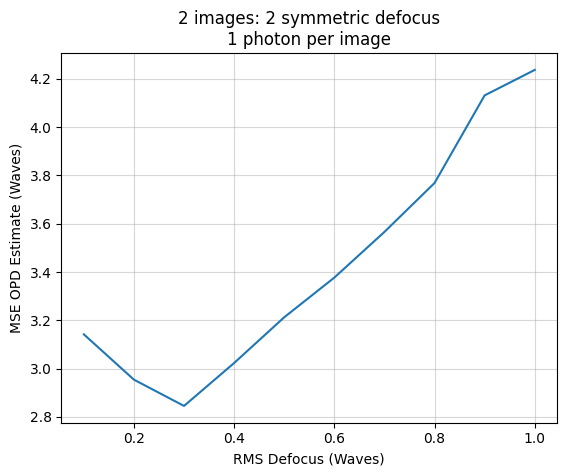

In [58]:
plt.plot(coeff_diversities.get(), cr_bounds[:, 1].get())
plt.xlabel('RMS Defocus (Waves)')
plt.ylabel('MSE OPD Estimate (Waves)')
plt.grid(alpha=0.5)
plt.title('2 images: 2 symmetric defocus\n1 photon per image')

Text(0.5, 1.0, '3.58')

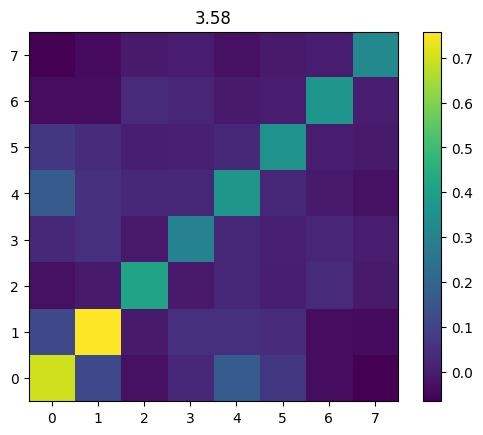

In [69]:
plt.imshow(cov_matrix.get(), origin='lower')
plt.colorbar()
plt.title(f'{cr_bound:.2f}')

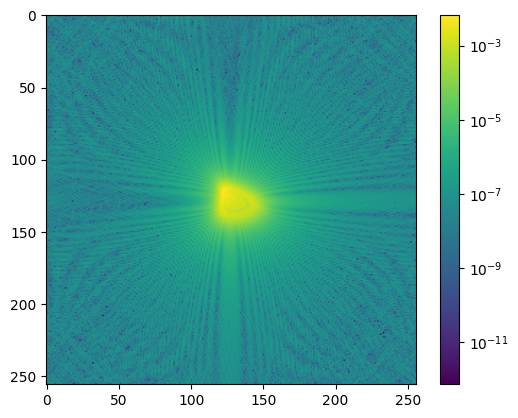

In [72]:
data = Is[1]
mask = A.astype('bool')

plt.imshow(data.get(), norm='log')
plt.colorbar()
# plt.title(f'{np.sum(data):.6f} sum\n{np.sqrt(np.mean(data[mask] ** 2)):.6f} rms')

Text(0.5, 1.0, '37841.846044 sum\n0.999211 rms')

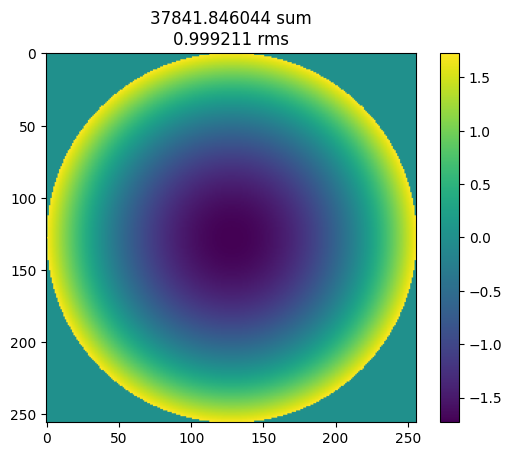

In [25]:
data = zernikes[0]
mask = A.astype('bool')

plt.imshow(data.get() * mask.get())
plt.colorbar()
plt.title(f'{np.sum(data):.6f} sum\n{np.sqrt(np.mean(data[mask] ** 2)):.6f} rms')